# Embeddings and Positional Encoding

Tokens are integers (notebook `05_tokenization.ipynb`), but neural networks operate on real
vectors. This notebook covers the two layers that turn token ids into the input of the
Transformer:

1. **Embeddings** — a learned lookup table mapping each token id to a dense vector
2. **Positional encoding** — injecting *order* information, since attention is order-agnostic:
   - **Sinusoidal** (the original Transformer)
   - **RoPE** (rotary), used by modern LLMs

These layers feed directly into `08_attention.ipynb` and `09_transformer.ipynb`.

In [22]:
# DATA SET LOADING AND PREPROCESSING
import sys
import os
import math
import random
import numpy as np
sys.path.append(os.path.abspath('..'))
from train import TensorValue
from train import SGD

# Load the text data
DATA_PATH = '../database/TinyStories-valid.txt'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    text_complete= f.read()

# Use only the MAX_CHARS first characters for speed (pure Python is slower)
MAX_CHARS = 10000
text = text_complete[:MAX_CHARS]
#lower case to reduce the number of unique characters
text = text.lower()
words = text.split()

print(f"Total characters in the file: {len(text_complete):,}")
print(f"Characters used: {len(text):,}")
print(f"\nFirst 300 characters:")
print("-" * 50)
print(text[:300])



Total characters in the file: 19,432,979
Characters used: 10,000

First 300 characters:
--------------------------------------------------
 spot. spot saw the shiny car and said, "wow, kitty, your car is so bright and clean!" kitty smiled and replied, "thank you, spot. i polish it every day."
after playing with the car, kitty and spot felt thirsty. they found a small pond with clear water. they drank the water and felt very happy. they


In [2]:
# Tokenizer
# For simplicity, we will treat each unique character as a token.
# In a real implementation, you might want to use subword tokenization (like BPE) or word-level tokenization.
# For more details on tokenization, see 05_tokenization.ipynb.

# Vocab: all characters are unique tokens
chars = sorted(list(set(''.join(text))))
stoi = {s: i for i, s in enumerate(chars)}
itos = {i: s for s, i in stoi.items()}
vocab_size = len(chars)

print(f"Vocab size: {vocab_size} unique characters")
print(chars)
print(f"First 40: {repr(''.join(chars[:40]))}")
print(f"Remaining: {repr(''.join(chars[40:]))}")

def tokenize(input_text):
    """Converts string to list of integers (token IDs)"""
    return [stoi[ch] for ch in input_text  if ch in stoi]

def detokenize(ids):
    """Converts list of IDs back to string"""
    return ''.join(itos.get(i, '?') for i in ids)


# Create training sequences (input → target pairs)
SEQ_LEN = 4  # context length
def create_batches(tokens, seq_len):
    """
    Creates (input, target) pairs for autoregressive training.
    
    input[i] = tokens[i : i+seq_len]
    target[i] = tokens[i+1 : i+seq_len+1]  ← shifted 1 position forward
    """
    batches = []
    for i in range(0, len(tokens) - seq_len - 1, seq_len):
        input_seq = tokens[i     : i + seq_len]
        target_seq = tokens[i + 1 : i + seq_len + 1]
        batches.append((input_seq, target_seq))
    return batches


all_tokens  = tokenize(text)
all_batches = create_batches(all_tokens, SEQ_LEN)

print(f"\nTotal tokens: {len(all_tokens)}")
print(f"Batches created: {len(all_batches)}")
print("\nExample (first 20 tokens):")
print(f"  Input: {repr(detokenize(all_batches[0][0][:20]))}")
print(f"  Target: {repr(detokenize(all_batches[0][1][:20]))}")
print("                 ^-- shifted 1 position forward")

Vocab size: 36 unique characters
['\n', ' ', '!', '"', "'", ',', '.', '<', '>', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', '|']
First 40: '\n !"\',.<>?abcdefghijklmnopqrstuvwxy|'
Remaining: ''

Total tokens: 10000
Batches created: 2499

Example (first 20 tokens):
  Input: ' spo'
  Target: 'spot'
                 ^-- shifted 1 position forward



## Embeddings: Token Representation

### The Problem

Neural networks work with real numbers. How can we represent a token (character/word) as a vector?

**One-hot** would be the obvious option:
- A vocabulary of 60 characters → a 60-dimensional vector, with a 1 at the token’s position
- Problem: it is sparse and does not capture semantic similarity ("cat" and "feline" are just as different from "house")

### The Solution: Embedding

An **embedding table** maps each token to a dense vector of dimension `d_model`:

```text
token_id  →  [0.3, -0.1, 0.8, 0.2, ...]   (`d_model` numbers)
```

- These vectors are **learned** during training
- Semantically similar tokens tend to have nearby vectors in embedding space
- It is simply a table lookup: `weights[token_id]`

### How to obtain the embedding vectors?
- We will initialize the embedding table with random values (e.g., Gaussian with small variance).
- During training, the model will learn to adjust these vectors to minimize the loss.
- Tokens that appear in similar contexts will have their embeddings adjusted in similar ways,  leading to similar vectors.

Train can be thought as the following steps:

token id→ embedding row → logits → loss → gradient → updated embedding row

The embedding vectors are updated via backpropagation, just like the weights of the model. The math is:

1. Embedding lookup:
$$e_t = E[t]$$

2. Output logits:
$$z_j = e_t^\top W_{\text{out}, j} + b_j$$

3. Softmax:
$$p_j = \frac{e^{z_j}}{\sum_k e^{z_k}}$$

4. Loss for the correct next token $y$:
$$\mathcal{L} = -\log p_y$$

5. `loss.backward()` computes gradients all the way back to:
- the used embedding row `E[token_id]`
- the output weights `W_out`
- the biases `b_out`

### Using Context Window

Instead of using one character to predict the next one, it uses a short context window of previous characters.

Idea:

- input: 4 previous characters
- each character id is mapped to its embedding
- the 4 embeddings are concatenated
- a linear layer predicts the next character
- loss backpropagates into all embedding rows used in that window

Mathematically, if the context is $[t_1, t_2, t_3, t_4]$:

$$x = [E[t_1]; E[t_2]; E[t_3]; E[t_4]]$$

$$z = xW + b$$

$$p_j = \frac{e^{z_j}}{\sum_k e^{z_k}}$$

$$\mathcal{L} = -\log p_{\text{target}}$$

That means every training example updates multiple character embeddings, not just one.






In [8]:
# Model Hyperparameters
D_MODEL = 8 # embedding dimension (vector size for each token)
LR = 0.05 # learning rate
N_EPOCHS = 50
CONTEXT = SEQ_LEN  # context length (same as sequence length for simplicity)

random.seed(42)  # for reproducibility
#--------------------------------------------

#Embedding Model parameters (weights)
# Embedding: [vocab_size × d_model]
E = TensorValue([[random.gauss(0, 0.1) for _ in range(D_MODEL)] for _ in range(vocab_size)], label="E")

#Linear layer: W: [d_model × vocab_size], b: [vocab_size]
# We concat the context embeddings → input dimension = context length × embedding dimension
D_IN = CONTEXT * D_MODEL  # input dimension = context length × embedding dimension
#W_out = [D_IN × vocab_size]
W_out = TensorValue([[random.gauss(0, 0.1) for _ in range(vocab_size)] for _ in range(D_IN)], label="W_out")
b_out = TensorValue([[0.0 for _ in range(vocab_size)]], label="b_out")
#all parameters for optimization
params = [E, W_out, b_out]


#------------------------

#Foarward pass
def forward_window(input_ids):
    """
    Forward pass for a single input sequence (window).
    """
    # 1. Embedding lookup
    # input_ids: [context length]
    # E: [vocab_size × d_model]
    # → embedded: [context length × d_model]
    embedded = E[input_ids]  # lookup embeddings for each token ID

    # 2. Flatten the embeddings (concat)
    # → x: [context length × d_model] → [context length * d_model]
    x = TensorValue.concat([emb for emb in embedded])  # stack embeddings into a single vector
    #reshape to [1 × D_IN] for matrix multiplication
    x = x.reshape(1, D_IN)

    # 3. Linear layer
    # W_out: [D_IN × vocab_size], b_out: [vocab_size]
    # x: [D_IN] → logits: [vocab_size]
    mul = x @ W_out  # [1 × D_IN] @ [D_IN × vocab_size] → [1 × vocab_size]
    logits = mul + b_out  # add bias
    return logits

In [19]:
def softmax_rows_tensor(x):
    row_max = x.data.max(axis=1, keepdims=True)
    shifted = x - TensorValue(row_max)
    exps = shifted.exp()
    return exps / exps.sum(axis=1, keepdims=True)

#Training loop
loss_history = []

#Optimizer: AdamW
optimizer = SGD(params, lr=LR)

for epoch in range(N_EPOCHS):
    total_loss = 0.0
    random.shuffle(all_batches)  # shuffle batches for better training
    for input_ids, target_ids in all_batches:
        # Forward pass
        logits = forward_window(input_ids)  # [vocab_size]

        # Backward pass and parameter updates 
        # Compute loss (cross-entropy)
        probs = softmax_rows_tensor (logits)  # [1 x vocab_size]
        loss = -probs[:,target_ids[-1]].log() # loss for the last token in the target sequence
        total_loss += loss.data[0]
        optimizer.zero_grad()  # reset gradients before backward pass
        loss.backward()  
        # Update parameters with AdamW optimizer
        optimizer.step()
            
    avg_loss = total_loss / len(all_batches)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{N_EPOCHS} - Loss: {avg_loss:.4f}")

Epoch 1/50 - Loss: 2.9592
Epoch 2/50 - Loss: 2.9058
Epoch 3/50 - Loss: 2.8718
Epoch 4/50 - Loss: 2.8449
Epoch 5/50 - Loss: 2.8225
Epoch 6/50 - Loss: 2.8032
Epoch 7/50 - Loss: 2.7864
Epoch 8/50 - Loss: 2.7714
Epoch 9/50 - Loss: 2.7580
Epoch 10/50 - Loss: 2.7459
Epoch 11/50 - Loss: 2.7349
Epoch 12/50 - Loss: 2.7248
Epoch 13/50 - Loss: 2.7155
Epoch 14/50 - Loss: 2.7069
Epoch 15/50 - Loss: 2.6989
Epoch 16/50 - Loss: 2.6914
Epoch 17/50 - Loss: 2.6844
Epoch 18/50 - Loss: 2.6778
Epoch 19/50 - Loss: 2.6716
Epoch 20/50 - Loss: 2.6657
Epoch 21/50 - Loss: 2.6602
Epoch 22/50 - Loss: 2.6549
Epoch 23/50 - Loss: 2.6498
Epoch 24/50 - Loss: 2.6450
Epoch 25/50 - Loss: 2.6404
Epoch 26/50 - Loss: 2.6360
Epoch 27/50 - Loss: 2.6318
Epoch 28/50 - Loss: 2.6277
Epoch 29/50 - Loss: 2.6238
Epoch 30/50 - Loss: 2.6200
Epoch 31/50 - Loss: 2.6164
Epoch 32/50 - Loss: 2.6129
Epoch 33/50 - Loss: 2.6095
Epoch 34/50 - Loss: 2.6062
Epoch 35/50 - Loss: 2.6030
Epoch 36/50 - Loss: 2.5998
Epoch 37/50 - Loss: 2.5968
Epoch 38/5

In [20]:
# Some embeddings learned:
print("\nSome embeddings learned:")
for ch in chars[:12]:
    idx = stoi[ch]
    vec = ' '.join(f'{x.data:+.3f}' for x in E[idx])
    print(f"{repr(ch):>5} -> [{vec}]")

# Predict the next token given a context
def predict_next_token(context_txt, topk=5):
    ids_context = tokenize(context_txt)
    assert len(ids_context) == CONTEXT, f"use exactly {CONTEXT} characters"

    logits = forward_window(ids_context)
    probs = softmax_rows_tensor(logits)

    ranking = sorted(range(vocab_size), key=lambda j: probs[0, j].data, reverse=True)

    print(f"\nContext: {repr(context_txt)}")
    for j in ranking[:topk]:
        print(f"  next={repr(itos[j])}  prob={probs[0, j].data:.4f}")

predict_next_token("once")
predict_next_token(" the")
predict_next_token("ing ")


Some embeddings learned:
 '\n' -> [-0.016 -0.058 -0.006 +0.157 +0.074 -0.188 -0.027 -0.124]
  ' ' -> [+0.209 -0.267 -0.451 +1.219 +1.665 -0.077 -1.178 -1.053]
  '!' -> [+0.024 +0.129 -0.002 -0.013 +0.064 -0.140 -0.031 +0.056]
  '"' -> [+0.074 -0.040 +0.056 +0.067 +0.088 -0.108 +0.025 -0.159]
  "'" -> [-0.267 -0.040 -0.116 +0.034 +0.043 -0.116 +0.082 -0.079]
  ',' -> [-0.179 -0.066 -0.020 +0.044 -0.162 +0.257 +0.205 +0.187]
  '.' -> [-0.156 -0.212 -0.034 +0.048 -0.223 +0.365 -0.035 +0.007]
  '<' -> [+0.066 +0.157 +0.053 +0.092 +0.155 -0.019 -0.127 -0.053]
  '>' -> [+0.102 -0.152 +0.011 +0.028 +0.010 +0.051 +0.032 +0.230]
  '?' -> [+0.062 -0.060 -0.064 -0.081 +0.098 -0.062 -0.006 +0.075]
  'a' -> [+0.027 +0.220 -0.408 -0.431 +0.104 +0.088 +0.104 -0.536]
  'b' -> [+0.033 +0.015 +0.099 +0.093 +0.041 -0.102 +0.153 +0.094]

Context: 'once'
  next=' '  prob=0.4569
  next='e'  prob=0.0537
  next='a'  prob=0.0415
  next='d'  prob=0.0411
  next='t'  prob=0.0323

Context: ' the'
  next=' '  prob

### Positional Encoding (PE)
The order problem:

The attention mechanism treats input tokens as a set, ignoring their order. To fix this, we add positional information to the token embeddings.

### Solution: Positional Encoding (PE)
Positional Encoding (PE) is a technique used to inject information about the relative or absolute position of tokens in a sequence. 
This allows the model to take the order of tokens into account when processing the input.

### How it works:
Positional encodings are added to the input embeddings at each position in the sequence.
These encodings have the same dimension as the embeddings, so they can be summed.
The encodings use sine and cosine functions of different frequencies to represent positions. 
We generate the positional encoding using the following formulas:

$$\text{PE}(pos, 2i)   = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$\text{PE}(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

where pos is the position and i is the dimension index. For each position, we calculate a unique encoding that captures its position in the sequence. This allows the model to learn patterns that depend on the order of tokens, such as syntax and grammar in language tasks.

- Values beteween -1 and 1, which helps with training stability.
- Different frequencies allow the model to learn relationships at different scales (e.g., nearby vs. distant tokens).
- The model can learn to attend to specific positions based on these encodings, improving its ability to capture sequential information.

Positional Encoding (12 positions, 8 dimensions):
 Pos |  sin d0  cos d1  sin d2  cos d3  sin d4  cos d5  sin d6  cos d7
----------------------------------------------------------------------
   0 | +0.0000 +1.0000 +0.0000 +1.0000 +0.0000 +1.0000 +0.0000 +1.0000
   1 | +0.8415 +0.5403 +0.0998 +0.9950 +0.0100 +1.0000 +0.0010 +1.0000
   2 | +0.9093 -0.4161 +0.1987 +0.9801 +0.0200 +0.9998 +0.0020 +1.0000
   3 | +0.1411 -0.9900 +0.2955 +0.9553 +0.0300 +0.9996 +0.0030 +1.0000
   4 | -0.7568 -0.6536 +0.3894 +0.9211 +0.0400 +0.9992 +0.0040 +1.0000
   5 | -0.9589 +0.2837 +0.4794 +0.8776 +0.0500 +0.9988 +0.0050 +1.0000
   6 | -0.2794 +0.9602 +0.5646 +0.8253 +0.0600 +0.9982 +0.0060 +1.0000
   7 | +0.6570 +0.7539 +0.6442 +0.7648 +0.0699 +0.9976 +0.0070 +1.0000
   8 | +0.9894 -0.1455 +0.7174 +0.6967 +0.0799 +0.9968 +0.0080 +1.0000
   9 | +0.4121 -0.9111 +0.7833 +0.6216 +0.0899 +0.9960 +0.0090 +1.0000
  10 | -0.5440 -0.8391 +0.8415 +0.5403 +0.0998 +0.9950 +0.0100 +1.0000
  11 | -1.0000 +0.0044 +0.8

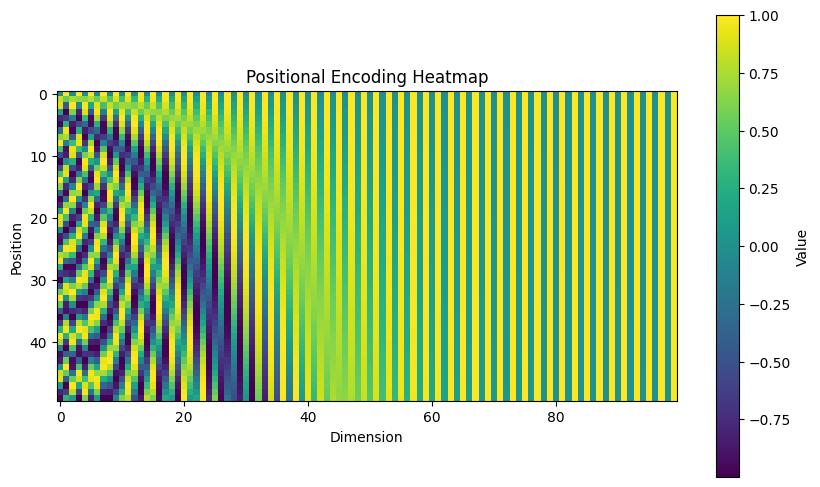

In [29]:
# Positional Encoding (PE)
class PositionalEncoding:
    """Sinusoidal positional encoding with correct even/odd frequency pairing."""

    def __init__(self, max_len: int, d_model: int):
        self.max_len = max_len
        self.d_model = d_model

        # Standard Transformer PE: even (2k) and odd (2k+1) share the same frequency for each pair k.
        position = np.arange(max_len, dtype=float).reshape(max_len, 1)
        even_dims = np.arange(0, d_model, 2, dtype=float)
        div_term = np.exp(-np.log(10000.0) * (even_dims / d_model))

        pe = np.zeros((max_len, d_model), dtype=float)
        pe[:, 0::2] = np.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = np.cos(position * div_term[: pe[:, 1::2].shape[1]])

        self.positional_encoding = TensorValue(pe)

    def forward(self, positions: list[int]) -> TensorValue:
        """Returns positional-encoding rows for absolute positions."""
        return self.positional_encoding[positions]


pe_demo = PositionalEncoding(12, 8).forward(list(range(12)))
print("Positional Encoding (12 positions, 8 dimensions):")
print(f"{'Pos':>4} | {'sin d0':>7} {'cos d1':>7} {'sin d2':>7} {'cos d3':>7} {'sin d4':>7} {'cos d5':>7} {'sin d6':>7} {'cos d7':>7}")
print("-" * 70)
for pos in range(12):
    vals = ' '.join(f'{pe_demo[pos][d].data:+.4f}' for d in range(8))
    print(f"{pos:>4} | {vals}")

print("\nSanity check (d2/d3 share the same frequency):")
for pos in [0, 1, 7]:
    expected_angle = pos / (10000 ** (2.0 / 8.0))  # k=1 -> dims 2 and 3
    got_sin = pe_demo[pos][2].data
    got_cos = pe_demo[pos][3].data
    print(
        f"pos={pos:2d} | sin(d2): got={got_sin:+.6f}, exp={math.sin(expected_angle):+.6f} | "
        f"cos(d3): got={got_cos:+.6f}, exp={math.cos(expected_angle):+.6f}"
    )

print("\nVisualize the first dimension (sinusoidal low frequency):")
for pos in range(12):
    val = pe_demo[pos][0]
    barra = int(abs(val.data) * 25)
    sinal = '+' if val.data >= 0 else '-'
    print(f"  pos {pos:2d}: {sinal}{'█' * barra}{'░' * (25 - barra)} ({val.data:+.3f})")

print("\nNotice: different positions -> different vectors -> the model knows where it is!")

# Generate heat map of positional encoding
import matplotlib.pyplot as plt
def plot_positional_encoding(PE):
    """Plots the positional encoding matrix as a heatmap."""
    plt.figure(figsize=(10, 6))
    plt.imshow([[PE[pos][d].data for d in range(PE[pos].shape[0])] for pos in range(PE.shape[0])], cmap='viridis')
    plt.colorbar(label='Value')
    plt.xlabel('Dimension')
    plt.ylabel('Position')
    plt.title('Positional Encoding Heatmap')
    plt.show()

print("\nHeatmap of positional encoding (50 positions, 100 dimensions):")
PE = PositionalEncoding(50, 100).forward(list(range(50)))
plot_positional_encoding(PE)

In [ ]:
# The input of Attention is a sequence of token embeddings with positional encodings added.
#Lets creating a simple example to illustrate how we add positional encodings to token embeddings before feeding them into the attention mechanism.
def add_positional_encoding(embedded, PE):
    """
    Adds positional encoding to the embedded input.
    embedded: [seq_len × d_model]
    PE: [max_seq_len × d_model]
    Returns: [seq_len × d_model] with positional encoding added
    """
    seq_len = len(embedded)
    return mat_add(embedded, PE[:seq_len])  # add PE for the first seq_len positions

# Example usage:
# Simulate embedded input (e.g., from an embedding layer)
embedded_example = [[Value(random.gauss(0, 0.1)) for _ in range(D_MODEL)] for _ in range(CONTEXT)]
PE_example = positional_encoding(100, D_MODEL)  # generate PE for up to 100 positions
embedded_with_pe = add_positional_encoding(embedded_example, PE_example)
print("\nExample of adding positional encoding to embedded input:")
for i in range(CONTEXT):
    emb = ' '.join(f'{x.data:+.3f}' for x in embedded_example[i])
    pe  = ' '.join(f'{x.data:+.3f}' for x in PE_example[i])
    combined = ' '.join(f'{x.data:+.3f}' for x in embedded_with_pe[i])
    print(f"Token {i}: Embedding: [{emb}] + PE: [{pe}] = Combined: [{combined}]")



### Rotary Positional Encoding (ROPE)
ROPE is an alternative to traditional positional encoding that allows for better generalization to longer sequences
Instead of adding positional encodings to the token embeddings, ROPE applies a rotation to the query and key vectors in the  attention mechanism based on their position. 

This allows the model to capture relative positional information and can generalize better to sequences longer than those seen during training.The equations for ROPE are:

$Q_{rot} = Q \cdot R(pos)$

$K_{rot} = K \cdot R(pos)$

where R(pos) is a rotation matrix that depends on the position of the token in the sequence. Whe can define R(pos) as:

$R(pos) = \begin{bmatrix}\cos(pos \cdot \theta) & -\sin(pos \cdot \theta) \\ \sin(pos \cdot \theta) & \cos(pos \cdot \theta) \end{bmatrix}$

where θ is a hyperparameter that controls the frequency of the rotations.

In [36]:
class Rope:
    """Rotary Positional Encoding (ROPE) for TensorValue matrices of shape [seq_len, d_model]."""

    def __init__(self, max_len: int, d_model: int):
        if d_model % 2 != 0:
            raise ValueError("d_model must be even for Rope")

        self.d_model = d_model
        self.max_len = max_len

        pair_dims = np.arange(0, d_model, 2, dtype=np.float32)
        inv_freq = np.exp(-np.log(10000.0) * (pair_dims / d_model))  # [d_model/2]
        positions = np.arange(max_len, dtype=np.float32).reshape(max_len, 1)
        angles = positions * inv_freq.reshape(1, -1)  # [max_len, d_model/2]

        self.cos_pos = TensorValue(np.cos(angles).astype(np.float32))
        self.sin_pos = TensorValue(np.sin(angles).astype(np.float32))

    def _interleave(self, even: TensorValue, odd: TensorValue) -> TensorValue:
        # Rebuild [..., d_model] from even and odd channels.
        cols = []
        for j in range(even.shape[1]):
            cols.append(even[:, j:j+1])
            cols.append(odd[:, j:j+1])
        return TensorValue.concat(cols, axis=1)

    def _apply_rope(self, x: TensorValue, cos: TensorValue, sin: TensorValue) -> TensorValue:
        x_even = x[:, 0::2]
        x_odd = x[:, 1::2]

        x_even_rot = x_even * cos - x_odd * sin
        x_odd_rot = x_odd * cos + x_even * sin

        return self._interleave(x_even_rot, x_odd_rot)

    def forward(self, q_matrix: TensorValue, k_matrix: TensorValue) -> tuple[TensorValue, TensorValue]:
        """Apply ROPE rotation to query and key tensors."""
        if q_matrix.shape != k_matrix.shape:
            raise ValueError("q_matrix and k_matrix must have the same shape")
        if len(q_matrix.shape) != 2:
            raise ValueError("q_matrix and k_matrix must be 2D tensors [seq_len, d_model]")

        seq_len, width = q_matrix.shape
        if width != self.d_model:
            raise ValueError("Last dimension must equal d_model")
        if seq_len > self.max_len:
            raise ValueError("Sequence length exceeds Rope max_len")

        cos = self.cos_pos[:seq_len]  # [seq_len, d_model/2]
        sin = self.sin_pos[:seq_len]  # [seq_len, d_model/2]

        q_rot = self._apply_rope(q_matrix, cos, sin)
        k_rot = self._apply_rope(k_matrix, cos, sin)
        return q_rot, k_rot


def pair_norm(x: TensorValue) -> np.ndarray:
    even = x[:, 0::2].data
    odd = x[:, 1::2].data
    return even ** 2 + odd ** 2


emb_rope = Rope(max_len=100, d_model=D_MODEL)
k_value = TensorValue(np.array([[random.gauss(0, 0.1) for _ in range(D_MODEL)] for _ in range(CONTEXT)], dtype=np.float32))
q_value = TensorValue(np.array([[random.gauss(0, 0.1) for _ in range(D_MODEL)] for _ in range(CONTEXT)], dtype=np.float32))

q_rot, k_rot = emb_rope.forward(q_value, k_value)

print("ROPE shapes:")
print(f"q: {q_value.shape} -> {q_rot.shape}")
print(f"k: {k_value.shape} -> {k_rot.shape}")

print("\nPair-norm preservation check (max abs diff):")
print(f"q max diff: {np.max(np.abs(pair_norm(q_value) - pair_norm(q_rot))):.8f}")
print(f"k max diff: {np.max(np.abs(pair_norm(k_value) - pair_norm(k_rot))):.8f}")

print("\nLast token before/after (q):")
before = ' '.join(f'{x:+.3f}' for x in q_value.data[-1])
after = ' '.join(f'{x:+.3f}' for x in q_rot.data[-1])
print(f"before: [{before}]")
print(f"after : [{after}]")

ROPE shapes:
q: (4, 8) -> (4, 8)
k: (4, 8) -> (4, 8)

Pair-norm preservation check (max abs diff):
q max diff: 0.00000000
k max diff: 0.00000000

Last token before/after (q):
before: [+0.036 -0.062 +0.041 -0.018 +0.072 -0.131 -0.140 -0.148]
after : [-0.027 +0.066 +0.044 -0.005 +0.076 -0.129 -0.140 -0.148]
